In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


In [2]:
import init_creds as creds
import sys
from langchain_openai import AzureChatOpenAI

sys.path.insert(1, '../../')

# # Configure Azure OpenAI And OpenAI Embeddings
# AZURE_OPENAI_KEY = os.getenv('OPENAI_API_KEY')
# AZURE_OPENAI_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT')
# AZURE_OPENAI_API_VERSION = os.getenv('OPENAI_API_VERSION')


AZURE_OPENAI_KEY = creds.get_api_key()
AZURE_OPENAI_ENDPOINT = creds.get_endpoint()
AZURE_OPENAI_API_VERSION = "2025-04-01-preview"

if not AZURE_OPENAI_KEY:
    raise ValueError("No AZURE_OPENAI_KEY set for Azure OpenAI API")
if not AZURE_OPENAI_ENDPOINT:
    raise ValueError("No AZURE_OPENAI_ENDPOINT set for Azure OpenAI API")

llm = AzureChatOpenAI(
    model="gpt-4o-mini",
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_KEY,
    api_version=AZURE_OPENAI_API_VERSION
)


In [3]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


In [4]:
# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" not in state["joke"] or "!" not in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}

In [5]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

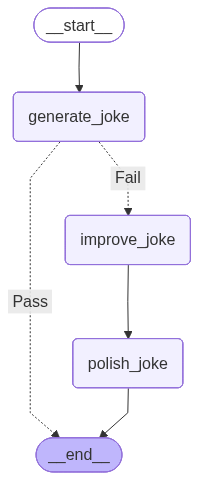

In [6]:
# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [7]:
# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

Initial joke:
Why was the cat sitting on the computer? 

Because it wanted to keep an eye on the mouse!

--- --- ---

Improved joke:
Why was the cat sitting on the computer? 

Because it wanted to keep an eye on the mouse and make sure it didn’t click away!

--- --- ---

Final joke:
Why was the cat sitting on the computer? 

Because it wanted to keep an eye on the mouse and make sure it didn’t click away… and then it accidentally hacked into the mainframe and took over the internet!
